# Time evolution of $\mathrm{Yb}$ spin-orbit coupled system with 2-body loss

- Units
    - $\hbar=1.0545\times 10^{-34} \,\mathrm{J}\cdot\mathrm{s}$
    - $E_r/\hbar = 8.8593 \,\mathrm{kHz}$
    - $k_r = \sin\left(\frac{\theta}{2}\right)\frac{2\pi}{556 \,\mathrm{nm}} = 6.9462\times10^6 \, \mathrm{m}^{-1}$

Where $\theta=75.854^\circ$
  
- Derived Units
    - $t_r = \hbar/E_r = 0.1129 \,\mathrm{ms}$
    - $m_r = \hbar^2 k_r^2 / 2 E_r = m_{\mathrm{Yb}} = 2.872×10^{-25} \, \mathrm{kg}$

- Hamiltonian
  
$$
\begin{equation}
    H=\sum_{\mathbf{k}}
    \begin{pmatrix}
        c_{\uparrow}^\dagger(\mathbf{k}) & c_{\downarrow}^\dagger(\mathbf{k})
    \end{pmatrix}
    \begin{pmatrix}
        \frac{\hbar^2(q_x-k_r)^2}{2m_{\mathrm{Yb}}} + \frac{\delta}{2} & \frac{\Omega_R}{2} \\
        \frac{\Omega_R}{2} & \frac{\hbar^2(q_x+k_r)^2}{2m_{\mathrm{Yb}}}-\frac{\delta}{2}
    \end{pmatrix}
    \begin{pmatrix}
        c_{\uparrow}(\mathbf{k}) \\
        c_{\downarrow}(\mathbf{k})
    \end{pmatrix}
    -\frac{1}{N}\frac{i}{2}\gamma\sum_{\mathbf{k}, \mathbf{k}', \mathbf{q}}c_\downarrow^\dagger(\mathbf{k}'+\mathbf{q})c_\uparrow^\dagger(\mathbf{k}-\mathbf{q})c_\uparrow(\mathbf{k})c_\downarrow(\mathbf{k}')
\end{equation}
$$

$q_x=[-2.5 k_r, ..., -0.5 k_r, 0, 0.5 k_r, k_r, ..., 3 k_r]$ for $L=12$

- parameters
  - $\hbar/\hbar = 1$
  - $k_r/k_r = 1$
  - $m_{\mathrm{Yb}}/m_r = 1$
  - $\delta/E_r = 4$
  - $\Omega_R/E_r = 3.5$
  - $\gamma/E_r = 0.25$


- basis
  
$$\mathcal{B}= \{c_{\sigma_1}^\dagger(\mathbf{k}_1)c_{\sigma_2}^\dagger(\mathbf{k}_2)\cdots c_{\sigma_n}^\dagger(\mathbf{k}_n)\ket{0}:\sigma_j=\uparrow,\downarrow, i_{\mathbf{k}_1}<i_{\mathbf{k}_2}<\cdots<i_{\mathbf{k}_n}\}$$
$$[H]_{\mathcal{B}}$$

In [1]:
!pip install diffrax

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.2/193.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.2/177.2 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.4/55.4 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.0/68.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.3/84.3 kB 7.5 MB/s eta 0:00:00


In [2]:
!unzip opalg

Archive:  opalg.zip
   creating: opalg/
   creating: opalg/lattice/
  inflating: opalg/lattice/multi_index.py  
  inflating: opalg/lattice/utils.py  
  inflating: opalg/lattice/visualization.py  
  inflating: opalg/lattice/__init__.py  
   creating: opalg/lattice/__pycache__/
  inflating: opalg/lattice/__pycache__/multi_index.cpython-312.pyc  
  inflating: opalg/lattice/__pycache__/utils.cpython-312.pyc  
  inflating: opalg/lattice/__pycache__/visualization.cpython-312.pyc  
  inflating: opalg/lattice/__pycache__/__init__.cpython-312.pyc  
   creating: opalg/sec_quant/
  inflating: opalg/sec_quant/utils.py  
  inflating: opalg/sec_quant/__init__.py  
   creating: opalg/sec_quant/__pycache__/
  inflating: opalg/sec_quant/__pycache__/__init__.cpython-312.pyc  
   creating: opalg/utils.py/
  inflating: opalg/__init__.py       
   creating: opalg/__pycache__/
  inflating: opalg/__pycache__/__init__.cpython-312.pyc  


In [16]:
import json
import os
import time
import itertools
import functools
import operator
import pickle
from pprint import pprint

import jax
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_platform_name', 'cpu')
import jax.numpy as jnp

import numpy as np
import tqdm
import matplotlib.pyplot as plt

import diffrax as dfx

from ybsoc import *

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
DATA_ROOT = '/content/drive/MyDrive/YbSOC_PA_DATA/decoherence_test/test_0'
os.makedirs(DATA_ROOT, exist_ok=True)

## System Definition

In [4]:
L = 12
N = 4

hbar = 1.

m_Yb = 1.

# q = 1.
# delta = 1.5486
# omega_R = 1.0585

k = 0.
delta = 0.
omega_R = 0.

gamma = 0.25
d = 2 * (2 * jnp.pi) / L

system = YbSOC2bodyLoss(
    d=d,
    lengths=[L,],
    n_particle=N,
    hbar=hbar,
    q=k,
    m_Yb=m_Yb,
    delta=delta,
    omega_R=omega_R,
    gamma=gamma,
    array_type='numpy'
)

hamiltonian = system.dense_hamiltonian(
    display_progress=True
)

100%|██████████| 10626/10626 [00:02<00:00, 3889.91it/s]


## Initial State Preparation

In [5]:
momentum_modes = (0, 1, 2, 11)

pure = system.get_momentum_eigenstate(
    (
        ((0,), 1),
        ((1,), 1),
        ((2,), 1),
        ((11,), 1),
    )
)

mixture = system.get_momentum_eigenstate(
    (
        ((0,), 1),
        ((1,), -1),
        ((2,), 1),
        ((11,), -1),
    )
)

prob_up = 1 - 0.31844
theta = 2 * np.arccos(np.sqrt(prob_up))  # p(up) = 2/3, p(down) = 1/3
phi = 0

spin_up_amp = np.cos(theta / 2)
spin_down_amp = np.exp(1j * phi) * np.sin(theta / 2)

spin_amps = {
    1: spin_up_amp,
    -1: spin_down_amp
}
spins = list(spin_amps.keys())

superposed = np.zeros_like(mixture)
for spin_config in itertools.product(spins, repeat=4):
    amp = np.prod([spin_amps[s] for s in spin_config])
    basis_config = tuple(
        ((mode,), spin) for mode, spin in zip(momentum_modes, spin_config)
    )
    basis = system.get_momentum_eigenstate(basis_config)
    superposed = superposed + amp * basis

## Simulation by exact propagator

In [6]:
eigenvalues, eigenvectors = np.linalg.eig(hamiltonian)

In [7]:
# initial_state = pure
# initial_state = mixture
initial_state = superposed

psi_tilde = np.linalg.solve(eigenvectors, initial_state)

t0 = 0
t1 = 0.8 / 0.1129
save_at = np.linspace(t0, t1, 101)
step_size = save_at[1] - save_at[0]

evolution_operator_diag = np.exp(-1j * eigenvalues * step_size / system.hbar)
psis = np.zeros((len(save_at), len(psi_tilde)), dtype=np.complex128)

psis[0, :] = np.einsum('ij,j->i', eigenvectors, psi_tilde)
for i in tqdm.trange(len(save_at)):
    psis[i, :] = np.einsum('ij,j->i', eigenvectors, psi_tilde)
    psi_tilde = evolution_operator_diag * psi_tilde

spin_up_numbers, spin_down_numbers = system.momentum_sp_expected_numbers_vectorized(psis)

100%|██████████| 101/101 [00:23<00:00,  4.31it/s]


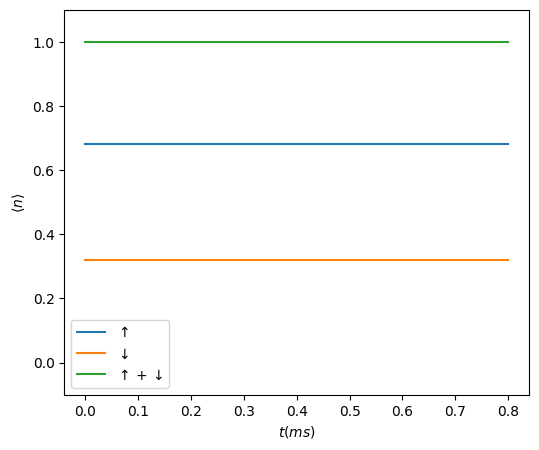

In [14]:
plt.figure(figsize=(6, 5))
t = save_at * 0.1129

# for i in range(8):
#     plt.plot(t, spin_up_numbers[:, i], label=f"$\\uparrow$, {i}")
#     plt.plot(t, spin_down_numbers[:, i], label=f"$\\downarrow$, {i}")

total_up = jnp.sum(spin_up_numbers, axis=1) / system.n_particle
total_down = jnp.sum(spin_down_numbers, axis=1) / system.n_particle

plt.plot(t, total_up, label="$\\uparrow$")
plt.plot(t, total_down, label="$\\downarrow$")
plt.plot(t, total_up + total_down, label="$\\uparrow + \\downarrow$")

plt.ylabel("$\\langle n \\rangle$")
plt.xlabel("$t (ms)$")
plt.ylim(-0.1, 1.1)

plt.legend()
plt.show()

## ODE Integration

\begin{equation}
\frac{d\rho}{dt}=-\frac{i}{\hbar}\left[H\rho-\rho H^\dagger\right]-\operatorname{off-diagonal}(\rho)/T_2
\end{equation}

- $T_2 = 0.4 \,\mathrm{ms}$

In [8]:
hamiltonian_jarr = jnp.array(hamiltonian, dtype=jnp.complex128)
initial_rho = jnp.outer(initial_state, initial_state.conj())      # |ψ〉〈ψ|

def drhodt(t, rho, args):
    (lam,) = args
    vne_term = (-1j / hbar) * (jnp.matmul(hamiltonian_jarr, rho) - jnp.matmul(rho, hamiltonian_jarr.T.conj()))
    decoherence_term = -lam * (rho - jnp.diag(jnp.diag(rho)))
    return vne_term + decoherence_term

term = dfx.ODETerm(drhodt)
solver = dfx.Dopri8()
saveat = dfx.SaveAt(ts=save_at)
stepsize_controller = dfx.PIDController(atol=1e-5, rtol=1e-5)

T2 = 0.4 / 0.1129

sol = dfx.diffeqsolve(
    term, solver, t0, t1, 1e-2, initial_rho, (1/T2,),
    saveat=saveat, stepsize_controller=stepsize_controller, max_steps=4096
)

rhos = sol.ys

/usr/local/lib/python3.11/dist-packages/equinox/_jit.py:55: UserWarning: Complex dtype support in Diffrax is a work in progress and may not yet produce correct results. Consider splitting your computation into real and imaginary parts instead.
  out = fun(*args, **kwargs)


In [35]:
num_op_diag = jnp.array(system.momentum_sp_num_op_diags())

def numper_expectation(rho):
    expected_numbers = jnp.einsum('ij,jj->i', num_op_diag, rho)
    up_total = jnp.sum(expected_numbers[0::2]).item().real
    down_total = jnp.sum(expected_numbers[1::2]).item().real
    return up_total, down_total

total_up_decoherence = np.zeros((save_at.size,))
total_down_decoherence = np.zeros((save_at.size,))

for i in range(save_at.size):
    total_up_decoherence[i], total_down_decoherence[i] = numper_expectation(rhos[i])

total_up_decoherence /= system.n_particle
total_down_decoherence /= system.n_particle

In [15]:
data_dir = os.path.join(DATA_ROOT, "data")
figs_dir = os.path.join(DATA_ROOT, "figs")

os.makedirs(data_dir, exist_ok=True)
os.makedirs(figs_dir, exist_ok=True)

In [ ]:
np.save(os.path.join(data_dir, "t.npy"), save_at)
np.save(os.path.join(data_dir, "up_no_decoherence.npy"), total_up)
np.save(os.path.join(data_dir, "down_no_decoherence.npy"), total_down)
np.save(os.path.join(data_dir, "up_decoherence.npy"), total_up_decoherence)
np.save(os.path.join(data_dir, "down_decoherence.npy"), total_down_decoherence)

with open(os.path.join(data_dir, "metadata.json"), "w+") as f:
    json.dump({
    "d": system.d,
    "lengths": system.lengths,
    "n_particle": system.n_particle,
    "hbar": system.hbar,
    "q": system.q.item(),
    "m_Yb": system.m_Yb,
    "delta": system.delta,
    "omega_R": system.omega_R,
    "gamma": system.gamma,
    "dim": system.dim,
    "k0": system.k0.item(),
    "T2": T2 * 0.1129
}, f, indent=4)

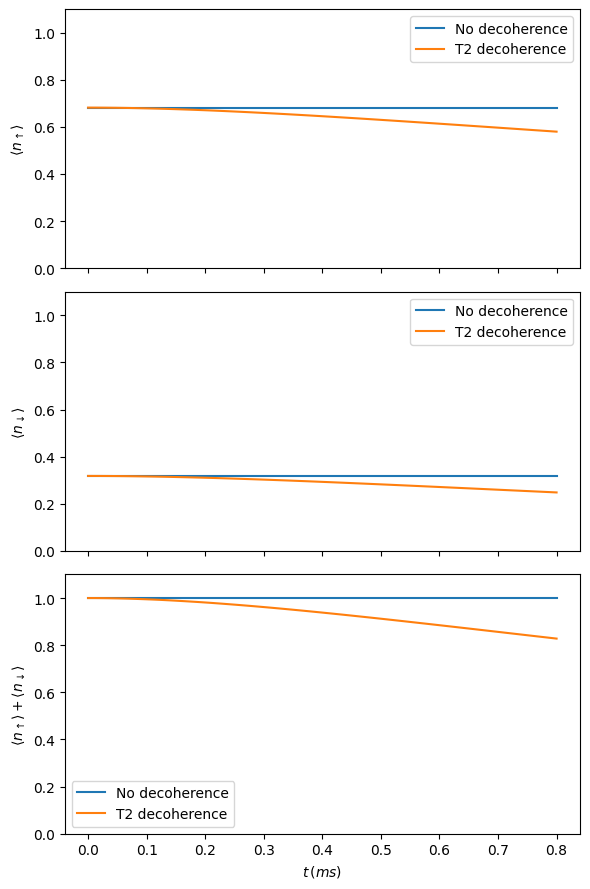

In [37]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(6, 9))

ax1.plot(t, total_up, label="No decoherence")
ax1.plot(t, total_up_decoherence, label="T2 decoherence")
ax1.set_ylabel("$\\langle n_{\\uparrow} \\rangle$")
ax1.set_ylim(0, 1.1)
ax1.legend()

ax2.plot(t, total_down, label="No decoherence")
ax2.plot(t, total_down_decoherence, label="T2 decoherence")
ax2.set_ylabel("$\\langle n_{\\downarrow} \\rangle$")
ax2.set_ylim(0, 1.1)
ax2.legend()


ax3.plot(t, total_up + total_down, label="No decoherence")
ax3.plot(t, total_up_decoherence + total_down_decoherence, label="T2 decoherence")
ax3.set_ylabel("$\\langle n_{\\uparrow} \\rangle + \\langle n_{\\downarrow} \\rangle$")
ax3.set_ylim(0, 1.1)
ax3.legend()
ax3.set_xlabel("$t\\,(ms)$")

plt.tight_layout()
plt.savefig(os.path.join(figs_dir, "plot.png"))
plt.show()